In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, Normalizer
import matplotlib.pyplot as plt
import statistics as st
from scipy import stats #https://stackoverflow.com/questions/23199796/detect-and-exclude-outliers-in-a-pandas-dataframe
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [2]:
df = pd.read_csv("./breast-cancer-train.csv")
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,4.230000e+02,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,...,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000
mean,3.258117e+07,13.858920,19.115485,90.053452,628.800473,0.095673,0.100523,0.082840,0.045811,0.179554,...,15.873489,25.403073,104.433475,834.582979,0.131046,0.243666,0.255843,0.109190,0.285464,0.083330
std,1.309702e+08,3.421658,4.297857,23.547931,337.185954,0.013868,0.051292,0.076309,0.037182,0.026406,...,4.634027,6.119756,32.216214,531.448772,0.022909,0.151891,0.201617,0.064248,0.060082,0.017580
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210
25%,8.692390e+05,11.555000,16.110000,74.065000,408.500000,0.085095,0.061475,0.028010,0.019880,0.161500,...,12.835000,20.810000,83.105000,504.300000,0.114000,0.138450,0.105500,0.062615,0.246150,0.070830
50%,9.084450e+05,13.160000,18.590000,84.550000,530.600000,0.095090,0.089180,0.054850,0.030700,0.178100,...,14.540000,25.070000,95.780000,648.300000,0.129600,0.205300,0.194300,0.091860,0.277200,0.079200
75%,8.910610e+06,15.145000,21.535000,99.155000,712.300000,0.105350,0.127000,0.118400,0.065995,0.194300,...,17.760000,29.335000,117.700000,969.200000,0.145800,0.311950,0.371550,0.153550,0.311300,0.091755
max,9.113205e+08,28.110000,39.280000,188.500000,2499.000000,0.142500,0.345400,0.426400,0.187800,0.304000,...,33.120000,49.540000,220.800000,3432.000000,0.209800,0.932700,1.252000,0.291000,0.663800,0.173000


In [3]:
df.shape

(423, 32)

# Limpieza de datos

Filas en las que falta algún dato, y columnas en las que falta algún dato.

In [4]:
vacio = df.isna()
filas_vacias = vacio.any(axis=1).sum()
colunmas_vacias = vacio.any(axis=0).sum()

filas_vacias, colunmas_vacias

(91, 10)

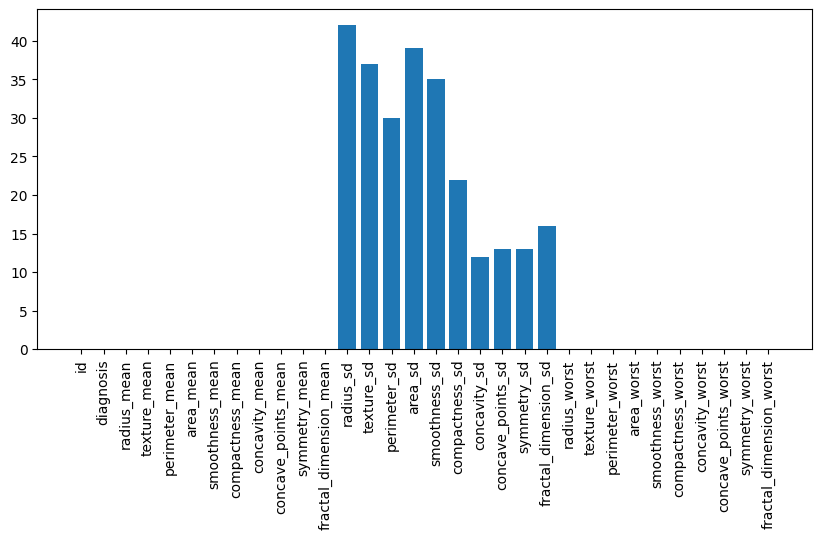

In [5]:
def count_plot(frecuencias):
    plt.figure(figsize=(10,5))
    plt.bar(frecuencias.index, frecuencias.values)
    plt.xticks(rotation=90)
    plt.subplots_adjust(bottom=0.2)
    #plt.show()
    plt.savefig("columnas-vacias.png", bbox_inches='tight')
total = vacio.sum(axis=0)
count_plot(total)

Se puede ver que de las 423 filas, a 91 les falta algún dato. Además, de las 32 columnas, sólo a 10 de ellas les falta algún dato, y todas esas columnas son de desviación estándar de los datos, por lo que no serán muy relevantes.from sklearn.impute import SimpleImputer, KNNImputer 

In [6]:
from sklearn.impute import SimpleImputer, KNNImputer

In [7]:
def eliminar_filas_vacias(df):
    """
    Elimina filas vacías o malformadas de un DataFrame.
    """
    return df.copy().dropna()

In [8]:
def rellenar_filas_vacias_con_media(df):
    """
    Rellena las filas con alguna columna vacía utilizando la media
    de dicha columna para rellenar los datos.
    """

    imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
    imp_mean.fit(df)
    
    df_updated = df.copy()
    vacio = df.isna().any(axis=0) > 0
    df_updated.loc[:, vacio] = imp_mean.transform(df)[:,vacio]
    
    return df_updated

In [9]:
def rellenar_filas_vacias_con_vecinos(df, vecinos=15):
    """
    Rellena las filas con alguna columna vacía utilizando los
    vecinos más similares a los datos. Recibe como argumento
    el número de vecinos a considerar.
    """

    knn_imputer = KNNImputer(n_neighbors=vecinos, weights="uniform")
    
    df_updated = df.copy()
    vacio = df.isna().any(axis=0) > 0
    df_updated.loc[:, vacio] = knn_imputer.fit_transform(df)[:,vacio]
    
    return df_updated

Podemos probar la diferencia que hay entre rellenar las columnas con la medisa de los datos, o utilizando los valores de los vecinos cercanos. Como se puede ver, la diferencia no es significativa, de menos del 1%.

In [10]:
df["diagnosis"] = df["diagnosis"].map({'M': 1, 'B': 0})
df_Simp = rellenar_filas_vacias_con_media(df)
df_Knimp = rellenar_filas_vacias_con_vecinos(df)

sca = StandardScaler()
dif = sca.fit_transform(df_Simp) - sca.fit_transform(df_Knimp)

print(f"{np.abs(dif).sum() / dif.size * 100} %")

0.612737199064422 %


<h3>OUTLIERS</h3>

In [11]:
def quitar_outliers(df, desviaciones=3):
    """
    Quita los datos que estén a más de un cierto número de desviaciones
    estándar por encima o por debajo de la media del conjunto de datos.
    """
    return df[(np.abs(stats.zscore(df)) < desviaciones).all(axis=1)]

In [12]:
df1 = rellenar_filas_vacias_con_vecinos(df)
df_p_outliers = quitar_outliers(df1)

df1.shape[0], df_p_outliers.shape[0]

(423, 362)

Como se puede ver, hay 61 elementos que se considerarían _outliers_ por estar demasiado alejados de la media.

<h3>SMOTE</h3>

Este es un método que permite balancear un dataset muy desbalanceado, generando muestras sintéticas de la clase minoritaria con interpolación simple. Esto nos sería útil, pues en nuestro dataset hay un cierto desbalanceo (hay 137 diagnósticos como maligno, y 285 como benigno).

In [13]:
df1 = rellenar_filas_vacias_con_vecinos(df)
sum(df1["diagnosis"] == 1), sum(df1["diagnosis"] == 0)

(137, 286)

In [14]:
def smote_agregar_samples(x, y):
    """
    Añade muestras sintéticas al dataset para balancear las clases
    del mismo. Las muestras son creadas mediante interpolación
    lineal del resto de muestras de la clase.
    """

    smote = SMOTE(random_state=25)
    return smote.fit_resample(x, y)

# Preparar Datos y Reducción de dimensionalidad (PCA)

A continuación vamos a crear unos métodos generales para extraer los datos del DataFrame, ignorando las columas que no nos interesan (ID), pre-procesando los datos (por ejemplo, eliminando filas vacías), añadiendo muestras sintéticas con SMOTE, estandarizando los datos, y reduciendo su dimensionalidad con un PCA.

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, Normalizer
import matplotlib.pyplot as plt

In [16]:
def extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=True,
    smote_augmentation=True,
    standarize=True,
    pca=None,
):
    """
    Extra los datos y clases de un DataFrame realizando un cierto
    procesado de los mismos.

    Args:
        - pre_process (function): método que se utilizará para preprocesar
            los datos (por ejemplo, eliminando o rellenando datos faltantes).
        - smote_augmentation (bool): si balancear o no el dataset añadiendo
            muestras sintéticas con SMOTE.
        - standarize (bool): si estandarizar o no cada columna del dataset
            para que ésta tenga media 0 y desviación típica 1.
        - pca (Optional[PCA]): permite opcionalmente aplicar reducción de
            dimensionalidad con un PCA precalculado.
    """

    # Convertir diagnosis de string a float.
    if df["diagnosis"].dtype == 'O':
        df["diagnosis"] = df["diagnosis"].map({'M': 1, 'B': 0})

    # Procesar filas vacías con el método especificado.
    if pre_process is not None:
        df = pre_process(df)

    if remove_outliers:
        df = quitar_outliers(df)

    # Separar en X e Y.
    x = df.iloc[:,2:].values
    y = df.iloc[:,1].values

    # Agregar ejemplos sintéticos con SMOTE.
    if smote_augmentation:
        x,y = smote_agregar_samples(x, y)

    # Estandarizar columna para que tengan media 0 y
    # desviación estándar 1.
    if standarize:
        sca = StandardScaler()
        x = sca.fit_transform(x)

    if pca is not None:
        x = pca.transform(x)
        sca = StandardScaler()
        x = sca.fit_transform(x)
    
    #norm = Normalizer()
    #x = norm.fit_transform(x)
    
    return x,y

def pca_dataframe(df, pre_process=rellenar_filas_vacias_con_vecinos, n_compontents=None):
    """
    Permite crear un PCA para la reducción de dimensionalidad de un DataFrame.
    Se puede especificar la función de pre-procesado de datos, y el número de 
    componentes al que se reducirá.
    """
    
    # Obtener datos estandarizados (sin SMOTE augmentation).
    x,_ = extraer_datos_xy(
        df, 
        pre_process,
        remove_outliers=True,
        standarize=True,
        smote_augmentation=False
    )
    pca = PCA(n_components=len(x[0]) if n_compontents is None else n_compontents)
    return pca.fit(x)

In [17]:
pca = pca_dataframe(df, n_compontents=7)
extraer_datos_xy(df, pca=pca, smote_augmentation=False)[0].shape

(362, 7)

In [18]:
extraer_datos_xy(df, pca=pca, smote_augmentation=True)[0].shape

(526, 7)

Para saber el número de dimensiones que reduciremos con el PCA en primer lugar vamos a crear una matriz de covarianza para comprobar cómo se correlacionados están los atributos del dataset.

In [19]:
import seaborn as sns

def plot_covarianza(matriz_covarianza):
    plt.figure(figsize=(8,8))
    sns.heatmap(matriz_covarianza)
    plt.savefig("covarianza.png", bbox_inches='tight')

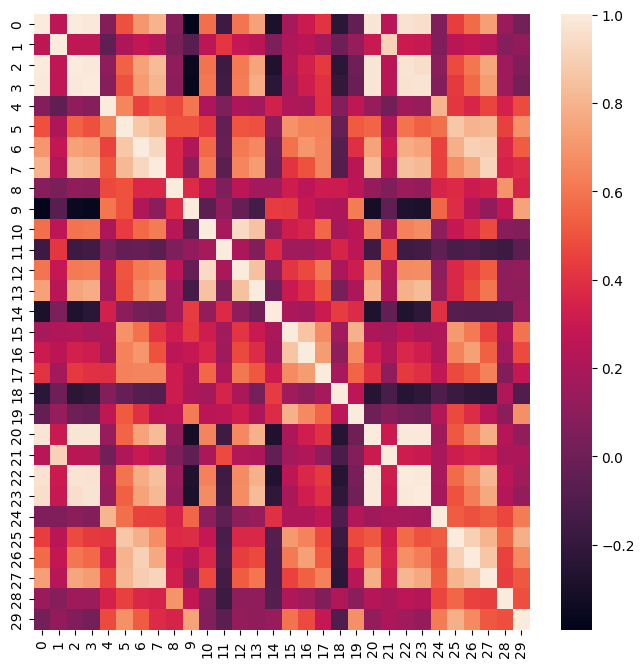

In [20]:
x,y = extraer_datos_xy(df, standarize=True, smote_augmentation=False)
df_covarianza = pd.DataFrame(x).cov()
plot_covarianza(df_covarianza)

Como se puede ver, hay bastantes grupos de atributos que tienen una correlación bastante alta (por ejemplo, el grupo de atributos de radio, perímetro y área, que obviamente estarán muy correlacionados). Por ello podemos saber que podemos reducir bastante la dimensionalidad de nuestros datos.

Para saber exactamente el número de dimensiones a reducir, haremos una gráfica de varianza acumulada para comprobar cuanta varianza se puede explicar para cada número de componentes del PCA.

In [21]:
def plot_variancia_acumulada(pca, percentiles=[90,95], colores=['r','g'], nombre="*"):
    var = pca.explained_variance_ratio_.cumsum()

    plt.plot([i for i in range(1, len(var)+1)], var,)

    # Dibujar los percentiles sobre la gráfica.
    for percentil,color in zip(percentiles, colores):
        p = np.argmax(var > (percentil/100.0)) + 1
        plt.axvline(x=p, color=color, linestyle='--', label=f'percentil {percentil} ({p})')
    
    plt.legend()

    plt.xlabel('Dimensiones')
    plt.ylabel('Varianza Acumulada')
    plt.grid(True)
    plt.savefig(f"codo-varianza-{nombre}.png", bbox_inches='tight')

Vamos a mostrar a continuación las dimensiones necesarias para explicar el 90% y 95% de la varianza del PCA para distintos tipos de técnicas para rellenar datos faltantes. Se puede ver que las tres técnicas vistas son muy parecidas.

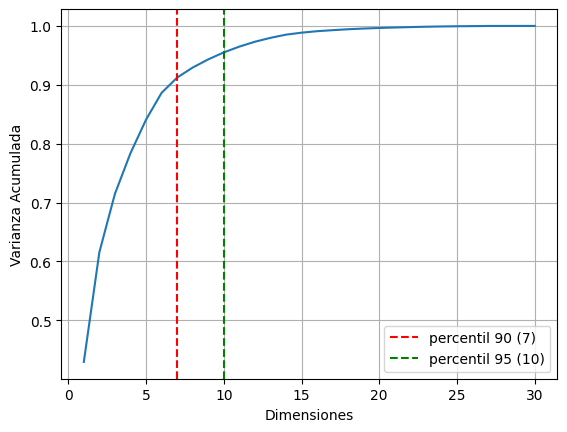

In [22]:
pca = pca_dataframe(df, pre_process=eliminar_filas_vacias)
plot_variancia_acumulada(pca, nombre='eliminar-filas')

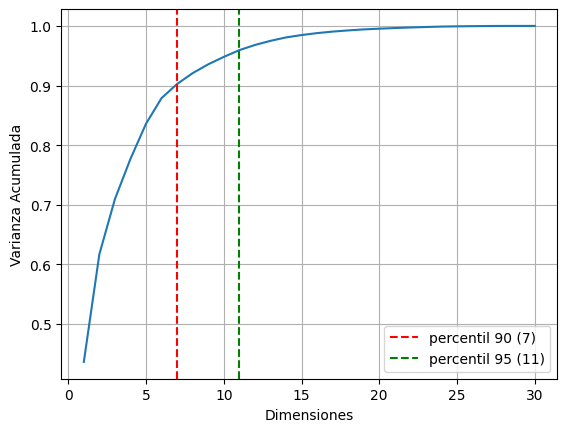

In [23]:
pca = pca_dataframe(df, pre_process=rellenar_filas_vacias_con_media)
plot_variancia_acumulada(pca, nombre='rellenar')

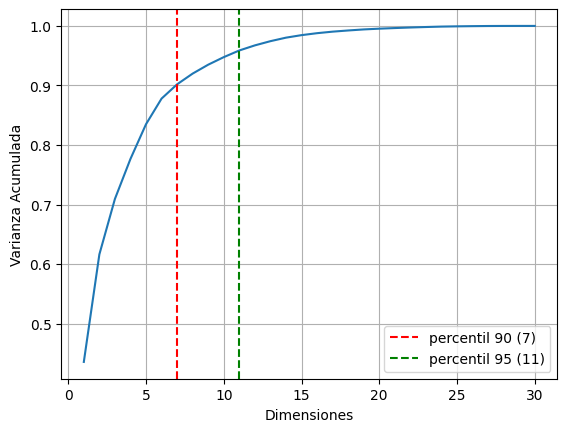

In [24]:
pca = pca_dataframe(df, pre_process=rellenar_filas_vacias_con_vecinos)
plot_variancia_acumulada(pca, nombre='rellenar')

Como se puede ver, no hay diferencia significativa entre los 3 tipos de métodos para eliminar filas vacías. En los 3 casos necesitaremos entre 7 y 11 componentes para explicar etre un 90 y 95% de la varianza de los datos.

<h2>LDA</h2>

In [25]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [26]:
def lda_array(df, pre_process=rellenar_filas_vacias_con_vecinos):
    """
    Permite crear un LDA para la reducción de dimensionalidad de un DataFrame.
    Se puede especificar la función de pre-procesado de datos.
    """
    
    # Obtener datos estandarizados (sin SMOTE augmentation).
    x,y = extraer_datos_xy(
        df, 
        pre_process, 
        standarize=True,
        smote_augmentation=False
    )
    lda = LDA()
    return lda.fit(x,y)

In [27]:
def plot_lda(x,y, lda):
    x_lda = lda.transform(x)

    plt.figure(figsize=(10, 2))

    maligno = y == 1
    plt.scatter(x_lda[maligno], y[maligno], color='red', label='Maligno')
    plt.scatter(x_lda[~maligno], y[~maligno], color='green', label='Benigno')
    plt.yticks([0,1])
    plt.xlabel('Componente Principal')
    plt.ylabel('Etiqueta')
    plt.legend()
    plt.savefig(f"lda.png", bbox_inches='tight')

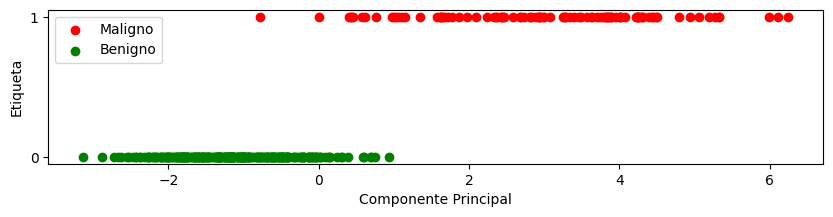

In [28]:
lda = lda_array(df)
x,y = extraer_datos_xy(df, smote_augmentation=False)
plot_lda(x,y,lda)

Se puede comprobar que las clases son _casi_ linealmente separables, aunque hay cierta superposición.

# Entrenamiento

In [29]:
from sklearn.model_selection import KFold, StratifiedKFold
import sklearn.metrics as metrics

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

import statistics as st
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

In [30]:
@ignore_warnings(category=ConvergenceWarning)
@ignore_warnings(category=UserWarning)
def CV1(
    X,
    Y,
    model_params,
    metric="f1",
    out_split=3,
    in_split=4,
):
    """
    Realiza validación cruzada anidada.

    Args:
        - X, Y: datos de entrenamiento.
        - model_params: array con las clases de los modelos a probar junti
            con sus parámetros. Todas las combinaciones de parámetros serán
            probadas.
        - metric: la métrica de los scores que se utilizarán para evaluaciones.
            Puede ser uno de los especificados en 
            https://scikit-learn.org/stable/modules/model_evaluation.html
        - out_split: número de folds del bucle exterior.
        - in_split: número de folds del bucle interior.
    """

    # Folds del dataset con balanceado de clases.
    fuera_cv = StratifiedKFold(n_splits=out_split, shuffle=True, random_state=25)
    dentro_cv = StratifiedKFold(n_splits=in_split, shuffle=True, random_state=25)

    # Inicializar resultados del bucle exterior.
    results_fuera = {}
    for model,params in model_params:
        results_fuera[model.__name__] = { 'best_index': [] }

    # Ir por cada uno de los folds probando los mismos modelos 
    # con todas las combinaciones de parámetros posibles.
    for i, (ixs_train_fuera, ixs_test_fuera) in enumerate(fuera_cv.split(X, Y)):
        # Datos de entrenamiento para el bucle exterior
        X_train_fuera = X[ixs_train_fuera]
        Y_train_fuera = Y[ixs_train_fuera]            

        for model,params in model_params:
            # Prueba todas las combinaciones de parámetros posibles.
            fitted_model = GridSearchCV(
                model(), 
                params, 
                cv=dentro_cv, 
                scoring=metric
            )
            fitted_model.fit(X_train_fuera, Y_train_fuera)

            # Guardamos los parámetros utilizados y el mejor índice.
            results_fuera[model.__name__]['best_index'].append(fitted_model.best_index_)
            results_fuera[model.__name__]['params'] = fitted_model.cv_results_["params"]
    
    # Realizar cross validation final con los mejores
    # parámetros de cada modelo.
    results = {}
    for model,params in model_params:
        # Encontrar el conjunto de parámetros que fue más veces el mejor
        # y seleccionarlos para realizar cross validation.
        index_best = st.mode(results_fuera[model.__name__]['best_index'])
        best_model = model(**results_fuera[model.__name__]['params'][index_best])
        
        model_csv = cross_validate(
            best_model, 
            X, 
            Y, 
            cv=fuera_cv, 
            return_estimator=True,
            scoring=metric
        )

        results[model.__name__] = {
            'best': model_csv["estimator"][np.argmax(model_csv["test_score"])],
            'scores': model_csv["test_score"]
        }

    return results

In [31]:
pca = pca_dataframe(df, n_compontents=7)
params = [
    (KNeighborsClassifier, {
        "n_neighbors": (1,2,3,6,9,11,14,20,25,30,35,40,45,50),
    }),
    (LogisticRegression, {
        "C": (0.01, 0.0125, 0.025, 0.05, 0.1, 0.15, 1, 10, 40, 50, 60, 100), 
        "penalty": (None, "l2"),
        "random_state": (25,)
    }),
    (DecisionTreeClassifier, {
        "max_depth": (2,3,4,5,6,8,9,10), 
        "min_samples_split": (2,3,4,5,6,7,8,9,10), 
        "min_samples_leaf": (1,2,3,4,5,6),
        "random_state": (25,)
    }),
    (MLPClassifier, { 
        "hidden_layer_sizes":([3],[4],[5],[6],[7],[3,3],[4,4], [4,4,4], [4,8,4]), 
        "learning_rate_init": (0.001, 0.01, 0.1), 
        "max_iter": (4000,),
        "random_state": (25,)
    })
]

# Resultados y parámetros elegidos

- KNeighborsClassifier: Este modelo ha sido probado de forma conjunta, y es el más sencillo de probar, pues hay un único hiperparámetro que toma valores discretos. En este caso, se ha decidido probar una gran cantidad de valores, desde pequeños a grandes. El número óptimo de vecinos varía bastante de ejecución a ejecución. La ejecución final con la que nos hemos quedado ha elegido K=45, obteniendo un F1 score de 92-97%

- LogisticRegression: se han probado bastantes valores de C de distintas escalas, al igual que se ha probado la regresión logística sin `penalty`. Al igual que KNeighborsClassifier, el número de parámetros óptimos varía bastante de ejecución a ejecución, desde C=0.025, hasta C=50. En la ejecución final con la que nos hemos quedado se ha elegido C=50, obteniendo un F1 score de 94-98%. Es consistentemente el modelo que consigue los mejores resultados.

- DecisionTreeClassifier: como en KNeighborsClassifier, los hiperparámetros toman valores discretos, por lo que es fácil probar todas las combinaciones de parámetros razonables que podríamos tener. Para la máxima profundidad se han probado todos los valores menores que 6, y algunos por encima de 6. Para el resto de hiperparámetros, se han probado todos los valores menores que 6 o 10. En la ejecución final con la que nos hemos quedado se ha elegido max_depth=5, min_samples_split=7, min_samples_leaf=1, obteniendo un F1 score de 90-95%. Es consistentemente el peor modelo de los 4.

- MLPClassifier: es el modelo más difícil de ajustar debido a que hay muchas combinaciones posibles de número de capas ocultas y tamaños de capas. Se ha decidido probar bastantes tamaños distintos de una sola capa, y un par de tamaños para 2 o 3 capas. No se ha probado con demasiadas neuronas, porque se ha comprobado que los mejores hiperparámetros corresponden con un número de neuronas reducidos. Se ha probado con un número de iteraciones elevado, y dos learning rates distintos, de 0.01 y 0.001. En la ejecución final con la que nos hemos quedado se ha elegido una única capa oculta de 3 neuronas, con un learning rate de 0.001, obteniendo un F1 score de 95-99%. Es el mejor modelo de los 4, muy cerca del regresor logístico.

A continuación se prueban los 4 modelos conseguidos con 4 ejemplos de test de otro dataset. Se puede ver que el regresor logístico y el MLP consiguen las predicciones correctas. Por otro lado, los otros 2 modelos tienen un falso negativo cada uno.

In [32]:
x,y = extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=True,
    smote_augmentation=True,
    standarize=True,
    pca=pca
)
res = CV1(
    x,
    y,
    params,
)

<h3>Entrenamos con el dataframe quitando los nulos

In [33]:
x,y = extraer_datos_xy(
    df,
    pre_process=eliminar_filas_vacias,
    remove_outliers=True,
    smote_augmentation=True,
    standarize=True,
    pca=pca
)
res_df_quitar = CV1(
    x,
    y,
    params,
)

<h3>Entrenamos con el dataframe rellenando con media

In [34]:
x,y = extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_media,
    remove_outliers=False,
    smote_augmentation=False,
    standarize=True,
    pca=pca
)
res_df_media= CV1(
    x,
    y,
    params,
)

<h3>Entrenamos con el dataframe rellenando con KNNImputer

In [35]:
x,y = extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=False,
    smote_augmentation=False,
    standarize=True,
    pca=pca
)
res_df_knn = CV1(
    x,
    y,
    params,
)

<h3>Entrenamos con el dataframe rellenando con KNNImputer y quitando outliers

In [36]:
x,y = extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=True,
    smote_augmentation=False,
    standarize=True,
    pca=pca
)
res_df_knn_outliers= CV1(
    x,
    y,
    params,
)

<h3>Entrenamos con el dataframe rellenando con KNNImputer y usando smote

In [37]:
x,y = extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=False,
    smote_augmentation=True,
    standarize=True,
    pca=pca
)
res_df_knn_smote = CV1(
    x,
    y,
    params,
)

<h3>Entrenamos con el dataframe rellenando con KNNImputer, quitando outliers y usando smote

In [38]:
x,y = extraer_datos_xy(
    df,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=True,
    smote_augmentation=True,
    standarize=True,
    pca=pca
)
res_df_knn_outliers_smote = CV1(
    x,
    y,
    params,
)

In [49]:
resultados = [res_df_quitar, res_df_media, res_df_knn, res_df_knn_outliers, res_df_knn_smote, res_df_knn_outliers_smote]
smotes = ["No", "No", "No", "No", "Si", "Si"]
outliers = ["No", "No", "No", "Si", "No", "Si"]
prepro = ["quitar", "media", "knn", "knn", "knn", "knn"]
param_names_knn = ["n_neighbors"]
param_names_rl = ["C", "penalty"]
param_names_tree = ["max_depth", "min_samples_split", "min_samples_leaf"]
param_names_mlp = ["hidden_layer_sizes","learning_rate_init","max_iter"]

In [50]:
def linea(iter, modelo, param_names, n_modelo, smotes = smotes, outliers = outliers, prepro = prepro):
    m = modelo["best"]
    params = []
    for i in param_names:
        params.append(str(i) + f"  = {m.get_params()[i]}")
    scores = modelo["scores"]
    best_scores = np.max(scores)
    media = f"{round(np.mean(scores),5)} +- {round(st.stdev(scores),5)}"
    return [
        n_modelo, *params, prepro[iter], smotes[iter], outliers[iter], best_scores, media
    ]

def tabla(resultados, nombre_modelo, params):
    nombres = ["nombre", *params, "preprocesamiento", "smote", "outliers quitados", "mejor score", "media"]
    rows = []
    for cont, i in enumerate(resultados):
        rows.append(linea(cont, i[nombre_modelo], param_names=params, n_modelo=nombre_modelo))
    return pd.DataFrame(rows, columns=nombres)

In [51]:
t_knn = tabla(resultados=resultados, nombre_modelo="KNeighborsClassifier", params=param_names_knn)
t_rl = tabla(resultados=resultados, nombre_modelo="LogisticRegression", params=param_names_rl)
t_tree = tabla(resultados=resultados, nombre_modelo="DecisionTreeClassifier", params=param_names_tree)
t_mlp = tabla(resultados=resultados, nombre_modelo="MLPClassifier", params=param_names_mlp)

<h1>RESULTADOS PROBANDO COMBINACIONES DE PREPROCESAMIENTO

In [52]:
t_knn

,nombre,n_neighbors,preprocesamiento,smote,outliers quitados,mejor score,media
0,KNeighborsClassifier,n_neighbors = 1,quitar,No,No,0.972973,0.96357 +- 0.00822
1,KNeighborsClassifier,n_neighbors = 3,media,No,No,0.917647,0.86684 +- 0.04404
2,KNeighborsClassifier,n_neighbors = 3,knn,No,No,0.919540,0.87206 +- 0.04205
3,KNeighborsClassifier,n_neighbors = 1,knn,No,Si,0.888889,0.87829 +- 0.0094
4,KNeighborsClassifier,n_neighbors = 25,knn,Si,No,0.944444,0.92449 +- 0.01783
5,KNeighborsClassifier,n_neighbors = 45,knn,Si,Si,0.954545,0.94974 +- 0.00434


In [53]:
t_rl

,nombre,C,penalty,preprocesamiento,smote,outliers quitados,mejor score,media
0,LogisticRegression,C = 0.01,penalty = l2,quitar,No,No,0.958333,0.95344 +- 0.00847
1,LogisticRegression,C = 10,penalty = l2,media,No,No,0.978261,0.93666 +- 0.03711
2,LogisticRegression,C = 10,penalty = l2,knn,No,No,0.978261,0.93666 +- 0.03711
3,LogisticRegression,C = 10,penalty = l2,knn,No,Si,0.953846,0.92788 +- 0.0227
4,LogisticRegression,C = 10,penalty = l2,knn,Si,No,0.984456,0.97354 +- 0.01457
5,LogisticRegression,C = 40,penalty = l2,knn,Si,Si,0.983240,0.96948 +- 0.02334


In [54]:
t_tree

,nombre,max_depth,min_samples_split,min_samples_leaf,preprocesamiento,smote,outliers quitados,mejor score,media
0,DecisionTreeClassifier,max_depth = 5,min_samples_split = 4,min_samples_leaf = 1,quitar,No,No,0.938776,0.9348 +- 0.00546
1,DecisionTreeClassifier,max_depth = 3,min_samples_split = 2,min_samples_leaf = 1,media,No,No,0.923077,0.89406 +- 0.03171
2,DecisionTreeClassifier,max_depth = 2,min_samples_split = 2,min_samples_leaf = 5,knn,No,No,0.883721,0.86141 +- 0.02051
3,DecisionTreeClassifier,max_depth = 3,min_samples_split = 2,min_samples_leaf = 4,knn,No,Si,0.892308,0.86795 +- 0.026
4,DecisionTreeClassifier,max_depth = 3,min_samples_split = 2,min_samples_leaf = 6,knn,Si,No,0.929730,0.92445 +- 0.00756
5,DecisionTreeClassifier,max_depth = 5,min_samples_split = 7,min_samples_leaf = 1,knn,Si,Si,0.947977,0.92937 +- 0.0195


In [55]:
t_mlp

,nombre,hidden_layer_sizes,learning_rate_init,max_iter,preprocesamiento,smote,outliers quitados,mejor score,media
0,MLPClassifier,"hidden_layer_sizes = [4, 4, 4]",learning_rate_init = 0.1,max_iter = 4000,quitar,No,No,0.986111,0.9729 +- 0.01306
1,MLPClassifier,hidden_layer_sizes = [7],learning_rate_init = 0.001,max_iter = 4000,media,No,No,1.000000,0.9381 +- 0.05967
2,MLPClassifier,hidden_layer_sizes = [7],learning_rate_init = 0.001,max_iter = 4000,knn,No,No,1.000000,0.93468 +- 0.06037
3,MLPClassifier,hidden_layer_sizes = [7],learning_rate_init = 0.01,max_iter = 4000,knn,No,Si,0.939394,0.92847 +- 0.00975
4,MLPClassifier,hidden_layer_sizes = [5],learning_rate_init = 0.001,max_iter = 4000,knn,Si,No,0.989583,0.98054 +- 0.01557
5,MLPClassifier,hidden_layer_sizes = [3],learning_rate_init = 0.001,max_iter = 4000,knn,Si,Si,0.994286,0.97699 +- 0.02072


<h1>TEST CON TODO EL PREPROCESADO

In [56]:
dftest = pd.read_csv("./breast-cancer-test1.csv")
xtest, ytest = extraer_datos_xy(
    dftest,
    pre_process=rellenar_filas_vacias_con_vecinos,
    remove_outliers=False,
    smote_augmentation=False,
    standarize=True,
    pca=pca
)

for model_name in res:
    print(f"{model_name} predicts")
    print(res[model_name]["best"].predict(xtest)) 
print("Test is")
print(ytest)

KNeighborsClassifier predicts
[0 0 0 1]
LogisticRegression predicts
[0 0 1 1]
DecisionTreeClassifier predicts
[0 0 0 1]
MLPClassifier predicts
[0 0 1 1]
Test is
[0 0 1 1]
